# Phase 4 — Monte Carlo + Sensitivity Analysis

Push 50,000 uncertain scenarios through the trained surrogates to get **probabilistic flood outputs**, then run **permutation + SHAP** sensitivity.

Design: `docs/superpowers/specs/2026-09-04-phase4-montecarlo-sensitivity-design.md`.

> **Prerequisite:** Phase 3 must have saved `models/*.joblib`. Needs `pip install shap`.

## 1. Config & load surrogates

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

def _find_root(marker="PROJECT_BRIEF.md"):
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / marker).exists():
            return cand
    return here

PROJECT    = _find_root()
MODELS_DIR = PROJECT / "models"
DATA_DIR   = PROJECT / "data"
SEED  = 42
N_MC  = 50_000

FEATURES = ["rain_mult", "imperv_mult", "surf_n", "infil_min", "pipe_n"]
PARAM_RANGES = {
    "rain_mult":   (0.7, 1.5),
    "imperv_mult": (0.7, 1.3),
    "surf_n":      (0.011, 0.030),
    "infil_min":   (0.05, 1.5),
    "pipe_n":      (0.011, 0.030),
}

peak_reg  = joblib.load(MODELS_DIR / "peak_regressor.joblib")
flood_clf = joblib.load(MODELS_DIR / "flood_classifier.joblib")
vol_reg   = joblib.load(MODELS_DIR / "flood_volume_regressor.joblib")
print("Loaded 3 surrogate models | N_MC =", N_MC)

Loaded 3 surrogate models | N_MC = 50000


## 2. Monte Carlo sampling + hard two-stage prediction

Draw 50k uniform samples over the training ranges, then: peak from the regressor, flood yes/no from the classifier, and volume from the volume regressor **only when the classifier says flood** (else 0).

In [2]:
rng   = np.random.default_rng(SEED)
lows  = np.array([PARAM_RANGES[f][0] for f in FEATURES])
highs = np.array([PARAM_RANGES[f][1] for f in FEATURES])
Xmc = pd.DataFrame(rng.uniform(lows, highs, size=(N_MC, len(FEATURES))), columns=FEATURES)

peak  = peak_reg.predict(Xmc)
flood = flood_clf.predict(Xmc).astype(int)
vol   = np.where(flood == 1, vol_reg.predict(Xmc), 0.0)
vol   = np.clip(vol, 0, None)          # flood volume can't be negative

mc = Xmc.copy()
mc["peak_discharge_cfs"] = peak
mc["flooded"]            = flood
mc["flood_vol"]          = vol
print(f"Monte Carlo complete: {N_MC:,} samples")
mc.head()

Monte Carlo complete: 50,000 samples


,rain_mult,imperv_mult,surf_n,infil_min,pipe_n,peak_discharge_cfs,flooded,flood_vol
0,1.319165,0.963327,0.027313,1.061184,0.012789,25.055025,0,0.000000
1,1.480498,1.156684,0.025935,0.235765,0.019557,23.999855,1,0.015687
2,0.996638,1.256059,0.023233,1.243004,0.019425,21.722315,1,0.002637
3,0.881791,1.032751,0.012213,1.250065,0.023002,18.013685,0,0.000000
4,1.306470,0.912716,0.029443,1.345026,0.025789,18.496111,1,0.007927


## 3. Probabilistic outputs

P(flooding), percentiles, and exceedance statements. Sanity: P(flood) should be near the ~35% training rate and mean peak near ~19.5 CFS.

In [3]:
p_flood = mc["flooded"].mean()
flooded_vol = mc.loc[mc["flooded"] == 1, "flood_vol"]
pct = [50, 90, 95, 99]

print(f"P(flooding) = {p_flood*100:.1f}%   (training rate ~35% -> sanity check)")
print(f"mean peak   = {mc['peak_discharge_cfs'].mean():.2f} CFS  (baseline ~19.9)\n")

print("Peak discharge (CFS) percentiles:")
for q in pct:
    print(f"  P{q:<2d}: {np.percentile(mc['peak_discharge_cfs'], q):6.2f}")

print("\nFlood volume (10^6 gal), flooded samples only:")
for q in pct:
    print(f"  P{q:<2d}: {np.percentile(flooded_vol, q):.4f}  ({np.percentile(flooded_vol, q)*1e6:,.0f} gal)")

print("\nExceedance probabilities:")
for thr in [20, 25, 30]:
    print(f"  P(peak > {thr} CFS)          = {(mc['peak_discharge_cfs'] > thr).mean()*100:5.1f}%")
for v in [0.005, 0.010, 0.020]:
    print(f"  P(flood_vol > {v*1e6:>6,.0f} gal) = {(mc['flood_vol'] > v).mean()*100:5.1f}%")

P(flooding) = 33.0%   (training rate ~35% -> sanity check)
mean peak   = 19.07 CFS  (baseline ~19.9)

Peak discharge (CFS) percentiles:
  P50:  18.37
  P90:  25.05
  P95:  27.24
  P99:  30.80

Flood volume (10^6 gal), flooded samples only:
  P50: 0.0077  (7,748 gal)
  P90: 0.0231  (23,061 gal)
  P95: 0.0291  (29,137 gal)
  P99: 0.0379  (37,919 gal)

Exceedance probabilities:
  P(peak > 20 CFS)          =  33.6%
  P(peak > 25 CFS)          =  10.2%
  P(peak > 30 CFS)          =   1.6%
  P(flood_vol >  5,000 gal) =  22.5%
  P(flood_vol > 10,000 gal) =  12.6%
  P(flood_vol > 20,000 gal) =   4.4%


### Distributions + exceedance curves

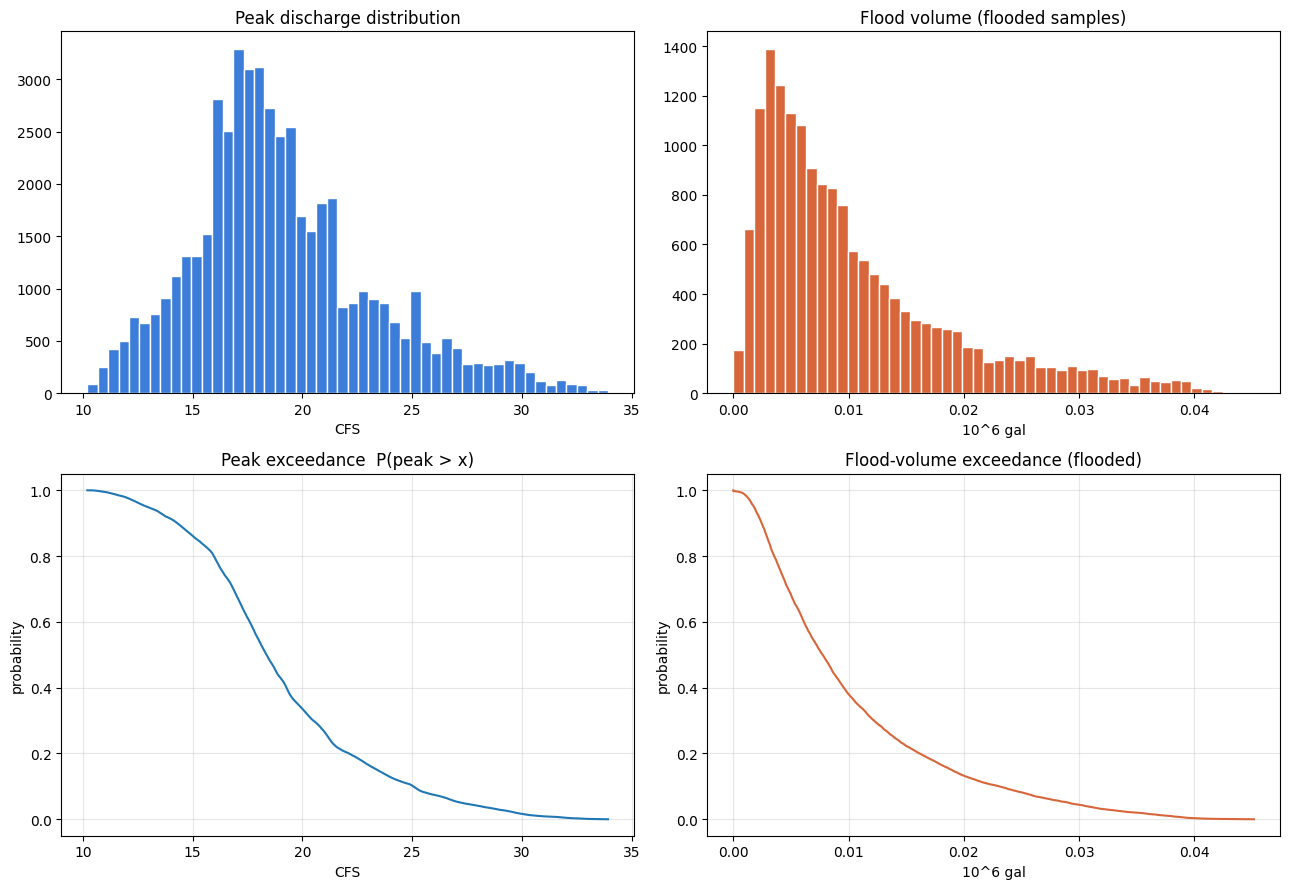

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax[0, 0].hist(mc["peak_discharge_cfs"], bins=50, color="#3b7dd8", edgecolor="white")
ax[0, 0].set_title("Peak discharge distribution"); ax[0, 0].set_xlabel("CFS")
ax[0, 1].hist(flooded_vol, bins=50, color="#d8663b", edgecolor="white")
ax[0, 1].set_title("Flood volume (flooded samples)"); ax[0, 1].set_xlabel("10^6 gal")

xs  = np.sort(mc["peak_discharge_cfs"].values)
exc = 1 - np.arange(1, len(xs) + 1) / len(xs)
ax[1, 0].plot(xs, exc); ax[1, 0].set_title("Peak exceedance  P(peak > x)")
ax[1, 0].set_xlabel("CFS"); ax[1, 0].set_ylabel("probability"); ax[1, 0].grid(alpha=0.3)

vs   = np.sort(flooded_vol.values)
excv = 1 - np.arange(1, len(vs) + 1) / len(vs)
ax[1, 1].plot(vs, excv, color="#d8663b"); ax[1, 1].set_title("Flood-volume exceedance (flooded)")
ax[1, 1].set_xlabel("10^6 gal"); ax[1, 1].set_ylabel("probability"); ax[1, 1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Sensitivity — permutation importance (all 3 targets)

Computed on the labeled dataset. This is where we finally see whether infiltration & imperviousness matter more for *flooding* than they did for peak discharge.

              peak  floods?  flood_volume
rain_mult    0.933    0.178         1.411
imperv_mult  0.511    0.124         1.148
surf_n       0.002    0.000         0.007
infil_min    0.001   -0.000         0.006
pipe_n       0.744    0.204         0.981


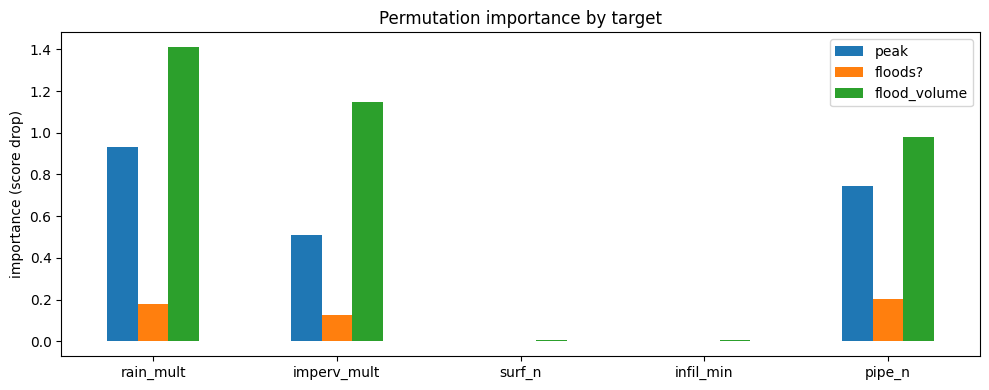

In [5]:
from sklearn.inspection import permutation_importance

df = pd.read_csv(DATA_DIR / "dataset.csv")
df = df[df["status"] == "ok"].reset_index(drop=True)
Xd = df[FEATURES]
flooded_mask = df["total_flood_vol"] > 0

imp = {}
r = permutation_importance(peak_reg, Xd, df["peak_discharge_cfs"],
                           n_repeats=15, random_state=SEED, scoring="r2")
imp["peak"] = pd.Series(r.importances_mean, index=FEATURES)

r = permutation_importance(flood_clf, Xd, flooded_mask.astype(int),
                           n_repeats=15, random_state=SEED, scoring="roc_auc")
imp["floods?"] = pd.Series(r.importances_mean, index=FEATURES)

r = permutation_importance(vol_reg, Xd[flooded_mask], df.loc[flooded_mask, "total_flood_vol"],
                           n_repeats=15, random_state=SEED, scoring="r2")
imp["flood_volume"] = pd.Series(r.importances_mean, index=FEATURES)

imp_df = pd.DataFrame(imp)
print(imp_df.round(3))
imp_df.plot.bar(figsize=(10, 4))
plt.title("Permutation importance by target"); plt.ylabel("importance (score drop)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 5. Sensitivity — SHAP (per-feature contributions + direction)

TreeExplainer on each XGBoost model. Beeswarm plots show both magnitude and direction (red = high feature value, blue = low).

C:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



===== SHAP summary: peak =====


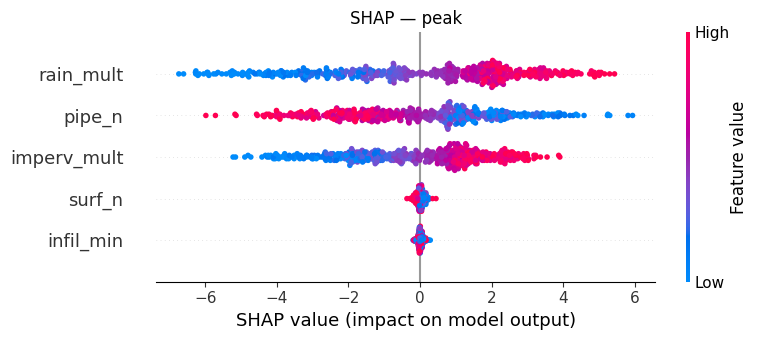


===== SHAP summary: floods? =====


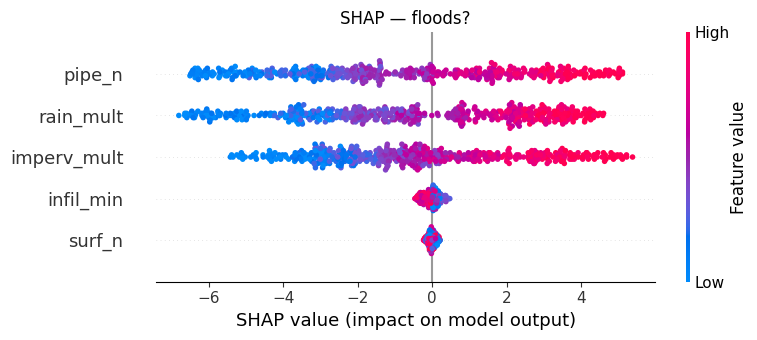


===== SHAP summary: flood_volume =====


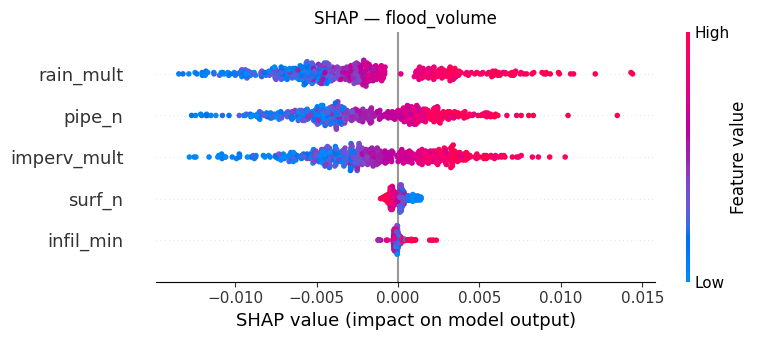

In [6]:
import shap

Xexp = Xd.sample(min(800, len(Xd)), random_state=SEED)

for name, model in [("peak", peak_reg), ("floods?", flood_clf), ("flood_volume", vol_reg)]:
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(Xexp)
    print(f"\n===== SHAP summary: {name} =====")
    shap.summary_plot(sv, Xexp, show=False)
    plt.title(f"SHAP — {name}"); plt.tight_layout(); plt.show()

## 6. Save results

In [7]:
mc.to_csv(DATA_DIR / "mc_results.csv", index=False)          # full 50k (gitignored)

summary = {
    "N_MC":                 N_MC,
    "P_flood_pct":          round(p_flood * 100, 2),
    "peak_mean":            round(mc["peak_discharge_cfs"].mean(), 2),
    "peak_P90":             round(np.percentile(mc["peak_discharge_cfs"], 90), 2),
    "peak_P95":             round(np.percentile(mc["peak_discharge_cfs"], 95), 2),
    "peak_P99":             round(np.percentile(mc["peak_discharge_cfs"], 99), 2),
    "floodvol_P95_flooded": round(float(np.percentile(flooded_vol, 95)), 5),
    "floodvol_P99_flooded": round(float(np.percentile(flooded_vol, 99)), 5),
}
pd.DataFrame([summary]).to_csv(DATA_DIR / "mc_summary.csv", index=False)
imp_df.to_csv(DATA_DIR / "sensitivity_permutation.csv")

print("Saved -> data/mc_summary.csv, data/mc_results.csv, data/sensitivity_permutation.csv")
pd.DataFrame([summary])

Saved -> data/mc_summary.csv, data/mc_results.csv, data/sensitivity_permutation.csv


,N_MC,P_flood_pct,peak_mean,peak_P90,peak_P95,peak_P99,floodvol_P95_flooded,floodvol_P99_flooded
0,50000,32.97,19.07,25.05,27.24,30.8,0.02914,0.03792
